# Single run experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import snag

from qiskit.circuit.library import efficient_su2

In [2]:
n_qubits = 3

field_str = 0.433
hamiltonian = snag.gen_hamiltonian_op(field=field_str, coupling=1.0, n_qubits=n_qubits)
print(hamiltonian)

eigenvalues, eigenvectors = np.linalg.eigh(np.array(hamiltonian))
e_gs = min(eigenvalues)
print("The ground state energy is ", e_gs)

SparsePauliOp(['XII', 'IXI', 'IIX', 'ZZI', 'IZZ', 'ZIZ'],
              coeffs=[-0.433+0.j, -0.433+0.j, -0.433+0.j, -1.   +0.j, -1.   +0.j, -1.   +0.j])
The ground state energy is  -3.1702265252407362


This circuit has  12 parameters


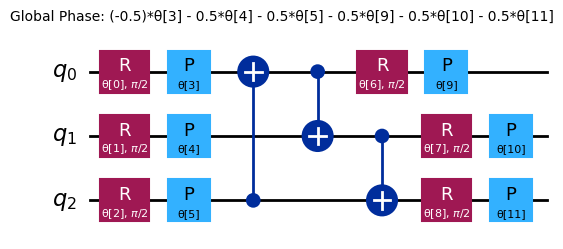

In [9]:
ansatz = efficient_su2(
    hamiltonian.num_qubits, entanglement="circular", reps=1
)

print("This circuit has ", ansatz.num_parameters, "parameters")
ansatz.decompose().draw("mpl")

In [10]:
opt_methods = ["Nelder-Mead", "Powell", "CG", "BFGS", "COBYLA"]
results = []

for method_name in opt_methods:
    vqe_result = snag.run_vqe(ansatz, hamiltonian, snag.compute_expectation, method=method_name)
    results.append(vqe_result)

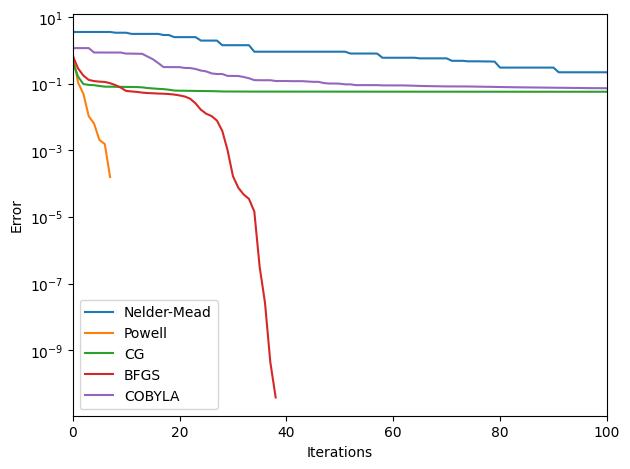

In [11]:
for meth_name, vqe_result in zip(opt_methods, results):
    plt.plot(vqe_result.cost_hist-e_gs, label=meth_name)

plt.xlim(0, 100)
plt.xlabel("Iterations")
plt.ylabel("Error")

plt.legend()
plt.yscale("log")
plt.tight_layout()